# Pràctica de Regressió Lineal amb regulariztació amb la base de dades "Mid-Atlantic Wage Data".

Daniel Suárez Angosto

## Objectius de la pràctica:
1. Treballar amb  la base de dades "Mid-Atlantic Wage Data".
   * #### Suposarem que és un problema que ens han encarregat resoldre i proporcionarem:
    1. Analitzar les variables i les dependències entre elles, mitjançant  una anàlisi exploratòria de les dades (EDA).
    2. Explicació de com les  variables d'entrada permeten explicar el <u>*valor del salari i la classe de feina*</u>.
    3. **Predicció de Salaris**: Utilitzar característiques demogràfiques, de salut i laborals per predir salaris o logaritmes de salaris.
    
3. Estudiarem el problema del **Sobreajustament o Overfitting**, i dos mètodes per  resoldre el problema:
    1. Regressió Ridge: regulariztació amb <u>*norma 2*</u>
    2. Lasso: regulariztació amb <u>*norma 1*</u>

## 1. Descripció del problema i la base de dades:
## Explicació de la Base de Dades: Mid-Atlantic Wage Data

La base de dades **Mid-Atlantic Wage Data** va ser creada amb l'objectiu de proporcionar un conjunt de dades per a l'anàlisi estadística i el desenvolupament de models en l'àmbit de l'aprenentatge automàtic i l'economia laboral. Aquesta base de dades recull informació sobre els salaris i altres factors rellevants de *3000* treballadors masculins en la regió del Mid-Atlantic dels Estats Units. Les dades es van recopilar per permetre:

- Estudis sobre la disparitat salarial basada en factors demogràfics com ara edat, raça, i nivell educatiu.
- Anàlisi de com el tipus de feina (industrial vs. informació) afecta els salaris.
- Investigació sobre la relació entre salut, assegurança mèdica, i guanys salarials.

Les dades van ser compilades manualment per Steve Miller d'Inquidia Consulting (anteriorment Open BI), utilitzant el Suplement de Març de 2011 del Current Population Survey (CPS), que és una enquesta mensual realitzada pel Bureau of Labor Statistics dels EUA i el Census Bureau, veure [1] o [2].


La base de dades conté informació com:
- **Demografia**: edat, raça, estat civil.
- **Educació i Treball**: nivell educatiu, tipus de feina.
- **Salut i Beneficis**: estat de salut i cobertura d'assegurança mèdica.
- **Ingressos**: salari brut i log del salari.
 
**Bibliografia**

- [1] **James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013).** *An Introduction to Statistical Learning with Applications in R*. Springer. 
- [2] **URL:** https://intro-stat-learning.github.io/ISLP/datasets/Wage.html


### <font color="blue"><b>1.1. Variables de la base de dades</b></font>   

| **Variable** | **Descripció** |
|--------------|-----------------|
| **year**     | Any en què es va registrar la informació del salari |
| **age**      | Edat del treballador |
| **maritl**   | Estat civil (categories: '1. Never Married', '2. Married', '3. Widowed', '4. Divorced', '5. Separated') |
| **race**     | Raça (categories: '1. White', '2. Black', '3. Asian', '4. Other') |
| **education**| Nivell educatiu (categories: '1. < HS Grad', '2. HS Grad', '3. Some College', '4. College Grad', '5. Advanced Degree') |
| **region**   | Regió de Mid-Atlantic |
| **jobclass** | Tipus de treball (categories: '1. Industrial', '2. Information') |
| **health**   | Nivell de salut (categories: '1. <=Good', '2. >=Very Good') |
| **health_ins**| Estat de l'assegurança de salut (categories: '1. Yes', '2. No') |
| **logwage**  | Logaritme del salari del treballador |
| **wage**     | Salari brut del treballador |

## <font color="red"><b>Exercici 1</b></font>
1. Per tal de clarificar els objectius d'aquesta pràctica, redactar un paràgraf resumint el tipus de base de dades utilitzada i l'objectiu de la pràctica.

En aquesta pràctica treballem amb la base de dades Mid-Atlantic Wage Data. Aquesta base de dades guarda informació sobre la vida de diferents treballadors amb la que volem donar una predicció de possibles salaris.

2. Abans d'aplicar mètodes d'Intel.ligència artificial, cal tenir una intuició sobre com influencien les variables observacionals  el resultat. A partir de la descripció de les variables escrigui breument la llista de variables que poden agumentar o disminuir el valor del salari. Igual per  la variable tipus de treball. Redactar  una explicació d'una línia per justificar cada cas.

year: No hauria de influir, a no ser que tinguessim dades d'anys molt separats en les que poguessim notar la inflació.

age: Podriem esperar que generalment un treballador a més edat tingués més experiencie pel qual cobres més.

maritl: Moltes possibles combinacions, depenent de la situació del treballador podria puajar o baixar el salari.

race: Depenent de biaix, potser que hi ha cert racisme o que notem algun moviment no igualitari.

education: Esperem, com a norma general, que una persona amb més educació cobri més que una persona amb menys educació.

region: Potser la zona on es trobi el treballador necessita més o menys poder adquisitiu, sol ser un punt important.

jobclass: Si he entés bé, tomant "Industrial" com treballs fisics o amb menys necessitat de coneixements, e "Information" com el contrari, entenem que hauria de tenir un major salir els treballadors del sector "Information".

health: Depenent del valor, entenem que MILLOR SALUT = MILLOR SOU (per diferents punts).

health_ins: Hauria de veure-ho, entenem que una persona que té assegurança als EUA tindra un nivell economic més alt.


# 1. Sobreajustament o Overfitting
**Sobreajustament** o **Overfitting** ocorre quan un model d'aprenentatge automàtic no només aprèn els patrons subjacents de les dades d'entrenament, sinó també el soroll o fluctuacions aleatòries. Com a resultat, el model funciona bé amb les dades d'entrenament però no generalitza bé amb noves dades, com les dades de test.

## 1.1. Per què l'Overfitting és un problema?

L'overfitting és un problema perquè el model "memoritza" les dades d'entrenament, incloent-hi el soroll i les fluctuacions aleatòries. Com a resultat, el model ajusta perfectament les dades d'entrenament, però no pot generalitzar bé a noves dades no vistes, com les dades de test o en situacions del món real.

Això provoca que el model tingui un rendiment pobre en la predicció de dades noves, ja que ha après patrons que no són generals ni útils fora del conjunt d'entrenament. En resum, un model que sofreix d'overfitting no és fiable ni robust per a situacions noves, la qual cosa limita la seva aplicabilitat.

### 1.1.1. Explicació amb una figura de l'Overfitting

**Idea bàsica**: massa paràmetres proporcionen massa graus de llibertat, i per tant, el model pot **ajustar-se al soroll** en lloc de captar la dependència funcional.

Per visualitzar l'overfitting, considerem un exemple  d'ajustar un model polinòmic a les dades. Suposem un conjunt de  dades amb sorroll i volem ajustar una corba:
1. Recta $y = ax +b$: **2** graus de llibertat: $P(x) = a_1x + a_0$
2. Polinomi de grau 10: **11** graus de llibertat:
$P(x) = a_{10}x^{10} + a_9x^9 + a_8x^8 + a_7x^7 + a_6x^6 + a_5x^5 + a_4x^4 + a_3x^3 + a_2x^2 + a_1x + a_0$

#### Casos que es poden donar:
 1. **Underfitting**: El model és massa senzill i no captura la tendència subjacent. Això passa quan utilitzem un model amb pocs graus de llibertat. El model no detecta els patrons reals de les dades.

   - **Exemple**: Utilitzar una línia recta quan les dades tenen una forma corbada.

 2. **Ajust perfecte**: El model ajusta perfectament les dades, modelant tots els patrons (inclòs el soroll). 

   - **Exemple**: Un polinomi que segueix la forma funcional que ha creat les dades.

 3. **Overfitting**: El model és massa complex i "memoritza" les dades, incloent-hi fluctuacions aleatòries o soroll. Funciona molt bé amb les dades d'entrenament però falla en dades no vistes (dades de test).

   - **Exemple**: Un polinomi de grau molt alt que fa moltes corbes per ajustar-se a cada punt de les dades d'entrenament.


![Underfitting vs. Overfitting](UnderfittingVsOverfitting.png)

## <font color="red"><b>Exercici 2</b></font>
1. Explicar qualitavament (tres linies) la diferència en quan a aproximació de la funció <u> $y= f(x) = ax+b$</u> entre la línea blava i la vermella.

La linea blava "Underfitting" és una recta que presenta tan pocs graus de llibertat que no s'adjusta adequadament a les dades de entrenament, és un mal model per simplicitat.

La linea vermella "Overfitting" és una corba, aquesta estarà composta amb massa graus de llibertat el que fa que es sobre adjusti a les dades d'entrenament. No només aprendrà lo basic per predir amb noves dades, sinò que aprendrà fins i tot el nivell de soroll aleatori de les dades d'entrenament el que fara que no funcioni correctament.

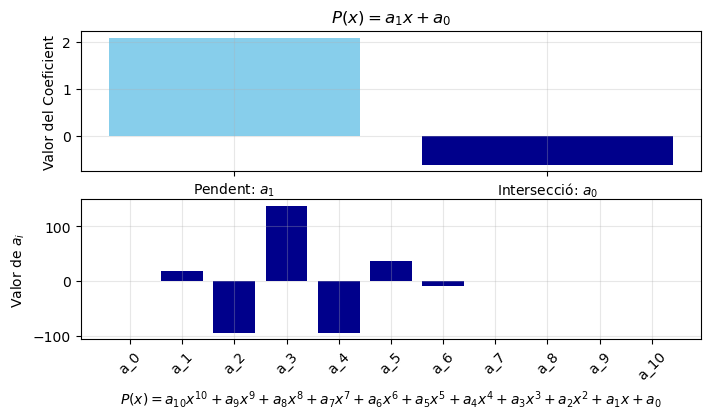

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
np.random.seed(45)
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.normal(0, 4, size=len(x))  # Afegim soroll
# Ajustem diferents models

# Regressió lineal (Underfitting)
linear_model = LinearRegression()
linear_model.fit(x.reshape(-1, 1), y)

# Regressió polinòmica (Overfitting)
poly_model = make_pipeline(PolynomialFeatures(degree=10), LinearRegression())
poly_model.fit(x.reshape(-1, 1), y)
# Obtenir els coeficients del model polinòmic
# Extraiem els coeficients del segon pas del pipeline (LinearRegression)
poly_coef = poly_model.named_steps['linearregression'].coef_
poly_features = poly_model.named_steps['polynomialfeatures']

# Crear figura amb dos subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4))
#fig.suptitle(' \n 1. P(x) = a_1x + a_0$, \n  2. Polinòmic de grau 10', fontsize=14)

# Plot 1: Model Lineal
# Representació dels coeficients del model lineal
ax1.bar(['Pendent: $a_1$', 'Intersecció: $a_0$'], 
        [linear_model.coef_[0], linear_model.intercept_],
        color=['skyblue', 'darkblue'])
ax1.set_title('$P(x) = a_1x + a_0$')
ax1.set_ylabel('Valor del Coeficient')
ax1.grid(True, alpha=0.3)

# Plot 2: Model Polinòmic
# Generem les etiquetes per als termes polinòmics
terms = [f'a_{i}' for i in range(len(poly_coef))]
ax2.bar(terms, poly_coef, color='darkblue')
#ax2.set_title('Coeficients del Model Polinòmic de grau 10')
ax2.set_xlabel('$P(x) = a_{10}x^{10} + a_9x^9 + a_8x^8 + a_7x^7 + a_6x^6 + a_5x^5 + a_4x^4 + a_3x^3 + a_2x^2 + a_1x + a_0$')
ax2.set_ylabel('Valor de $a_{i}$')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)


## <font color="red"><b>Exercici 3</b></font>
1. Explicar la diferència entre els coeficients dels models. Què pot significar, que en el model complicat, un terme estigui multiplicat per 100 i un altre per -100?, expliqui breument que li pasarà a un error de modelatge o al sorroll de les dades.

El que passa és que en el model complicat els coeficients estàn intentant seguir el valor de les dades més el soroll, el que fa que els coeficients oscil·lin de gran forma. En canvi en el model simple és el contrari, no podem adjustar-nos tant. 

El que pasarrà amb l'error es que si el mirem passant les dades de entrenament aquest serà minim, però en el moment en el que passem altres dades l'error serà molt més gran.

2. Raoniu, en dues línies, per què limitar els valors dels coeficients pot servir per millorar-ne les prestacions.

Simplement si limitem el valor dels coeficients, no tindrem tantes oscilacions, cosa que ens pot millor el resultat del model i de l'error.

3. Expliqui en dues línies, per què reduir el nombre de paràmetres redueix la flexibilitat en l'ajustament del model.

Com ja hem vist abans intentem reproduir amb una funció matematica les nostres dades de entrenament, per això si reduïm el nombre de parametres la nostra funció passarà a ser una mica més simple. Això pot ajudar a que millorem el model, ja que aquesta no podre aprendre tant l'error, però si ho reduïm massa potser que la nostra funció no segueix la tendencia de les dades.

## <font color="blue"><b>Objectiu: Seleccionar variables útils i el.liminar les espuries </b></font>

### <font color="blue"><b> Compte: correlacions accidentals.</b></font>

# 2. Regressió Ridge i Lasso: Definicions Formal

## 2.1. Regressió Ridge

La regressió Ridge és una tècnica de regularització que afegeix un terme **penalització a la funció d'error** de la regressió lineal. El propòsit és prevenir el **sobreajustament (overfitting)** reduint la magnitud dels coeficients. La funció de cost per a la regressió Ridge és:

$ J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2 + \alpha \sum_{j=1}^{p} \beta_j^2 $

On:
- $ n $ és el nombre d'observacions.
- $ p $ és el nombre de característiques.
- $ y_i $ és l'objectiu per a l'observació $ i $.
- $ x_{ij} $ són els predictors per la variable $j$.
- $ \beta_0 $ és el terme independent o intercept.
- $ \beta_j $ són els coeficients dels predictors $ x_{ij} $.
- $ \alpha $ és el paràmetre de regularització (hiperparàmetre). Valors més alts d'$ \alpha $ resulten en una penalització més gran dels coeficients.

La regularització de Ridge té l'efecte de **reduir tots els coeficients $ \beta_j$**.
* *Utilitat*: cas en que tots els predictors són importants però necessitem controlar el seu impacte.

## 2.2. Regressió Lasso

La regressió Lasso (Least Absolute Shrinkage and Selection Operator) també és un mètode de regularització, però utilitza una funció de penalització diferent que pot **reduir alguns coeficients exactament a zero**.
* *Utilitat*: Selecció automàtica de característiques (variable $j$), es a dir, es determina quins $ x_{ij} $  son rellevants per la predicció.
* La funció de cost per a la regressió Lasso és:

$ J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2 + \alpha \sum_{j=1}^{p} |\beta_j| $

On:
- Les definicions de $ n $, $ p $, $ y_i $, $ x_{ij} $, $ \beta_0 $, i $ \beta_j $ són les mateixes que per a la regressió Ridge.
- $ \alpha $ és el paràmetre de regularització. Com més alt sigui $ \alpha $, més coeficients seran reduïts a zero.

La regularització de Lasso és especialment útil quan es tracta de datasets amb moltes característiques on es vol seleccionar un subconjunt d'elles per simplificar el model.

## 2.3. Comparació:
- **Ridge**: Redueix tots els coeficients però no els fa arribar a zero. És millor quan es sospita que totes les característiques són rellevants.
- **Lasso**: Pot fer que alguns coeficients siguin zero, efectivament seleccionant característiques. És ideal per a la selecció de característiques i models més interpretables.

## 2.4. Interpretació del Paràmetre $\alpha$

- $\alpha$ és controla la flexibilitat d'ajustament en ambdós models:
  - Si $\alpha$ és massa petit, el model es comporta com una regressió lineal sense penalització.
  - Si $\alpha$ és massa gran, el model pot subajustar les dades.

Per determinar el millor valor de $\alpha$, sovint s'utilitza una cerca per **cross-validation**.

**Nota:**  Mes endavant explicarem el mètode de **cross-validation**.

# 3. Part pràctica.

* ###  Primer carreguem les llibreries de python 
* ###  Desprès carreguem la base de dades


#### Carreguem les llibreries 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

#### Lectura de la base de dades.

In [3]:
file_path = 'Wage.csv'  

# Llegim el fitxer CSV i l'emmagatzem al DataFrame
df = pd.read_csv(file_path)
# Veurem una mostra de les dades
df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


### Mirem el tipus de dades del DataFrame per si s'han de transformar valors

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   maritl      3000 non-null   object 
 3   race        3000 non-null   object 
 4   education   3000 non-null   object 
 5   region      3000 non-null   object 
 6   jobclass    3000 non-null   object 
 7   health      3000 non-null   object 
 8   health_ins  3000 non-null   object 
 9   logwage     3000 non-null   float64
 10  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 257.9+ KB


In [5]:
object_cols = df.select_dtypes(include=['object']).columns

# iterem en la llista de columnes
for col in object_cols:
  print("_"*40)
  unique_values = df[col].unique()
  print(f"Valors unics per la columna '{col}':")
  print(unique_values)

________________________________________
Valors unics per la columna 'maritl':
['1. Never Married' '2. Married' '4. Divorced' '3. Widowed' '5. Separated']
________________________________________
Valors unics per la columna 'race':
['1. White' '3. Asian' '4. Other' '2. Black']
________________________________________
Valors unics per la columna 'education':
['1. < HS Grad' '4. College Grad' '3. Some College' '2. HS Grad'
 '5. Advanced Degree']
________________________________________
Valors unics per la columna 'region':
['2. Middle Atlantic']
________________________________________
Valors unics per la columna 'jobclass':
['1. Industrial' '2. Information']
________________________________________
Valors unics per la columna 'health':
['1. <=Good' '2. >=Very Good']
________________________________________
Valors unics per la columna 'health_ins':
['2. No' '1. Yes']


## <font color="red"><b>Exercici 4</b></font>
1. Recordatori d'altres pràctiques. En una línia, quin mètode de Pandas es pot utilitzar per transformar categories a valors numèrics?
   
En les pràctiques anteriors hem utilitzat el métode .map() per pasar valors no numérics a numérics.


# 3.1. Anàlisi exploratòria de dades (EDA)

## 3.1.1. Entendre l'estructura del DataFrame.
###  **Recordar Metafora:**  un full excel.


### Anàlisi descriptiva de les columnes numériques

In [6]:

print(df[['year', 'age', 'logwage', 'wage']].describe().round(3))

           year       age   logwage      wage
count  3000.000  3000.000  3000.000  3000.000
mean   2005.791    42.415     4.654   111.704
std       2.026    11.542     0.352    41.729
min    2003.000    18.000     3.000    20.086
25%    2004.000    33.750     4.447    85.384
50%    2006.000    42.000     4.653   104.922
75%    2008.000    51.000     4.857   128.680
max    2009.000    80.000     5.763   318.342


## <font color="red"><b>Exercici 5</b></font>
1. Apartir l'instrucció df_DataBase.describe(),comparar  la mitjana aritmètica i mediana (percentil 50%)  i les desviacions estandard. Expliqueu en una línea si hi ha alguna variable que es devii de la distribució Gausiana. Observar la diferència entre log salari i el salari sense processar.

MITJANA ARITMÉTICA = MEAN

MEDIANA/PERCENTIL 50 = 50%

Sabem que per que una VA sigui Gaussiana, se ha de cumplir mean ~= 50%. Esto se cumple en todas las variables, menos en "wage" que presenciamos que no serà una Gaussiana simétrica, sino probablemente asimétrica. Per altre banda, la desviació estandard ens marca el que varien els diferents resulatats a partir de la mediana. Podem notar que en "wage" tenim una std molt més gran que en "logwage" el que ens indica que amb la transformació la reduïm.
   
2. Expliqui en una línea perquè caldrà estandaritzar les variables.

Com passa sempre, hi hauran varibales amb diferents magnituds i voldrem que totes tinguin la mateixa importància, per qual cosa tenim que estandaritzar les variables. De forma que totes tindràn, mitjana = 0 i desviació = 1.


## 3.1.2.  EDA dels Salaris

El següent codi realitza tres diagrames per entendre  la distribució i les relacions entre les variables  de la base de dades de salaris:

1. Histograma: Mostra la distribució dels salaris amb una tendència (KDE - Kernel Density Estimate). 
2. Diagrama de dispersió (scatter) amb Ajust Polinòmic: Aquest gràfic mostra la relació entre l'edat i el salari, amb una regressió polinòmica de segon grau per capturar possibles tendències no lineals.
3. Correlació  entre variables: Correlació entre edat, logaritme del salari i el salari brut. Les cel·les més clares indiquen una correlació positiva forta, mentre que les més fosques indiquen una correlació negativa.

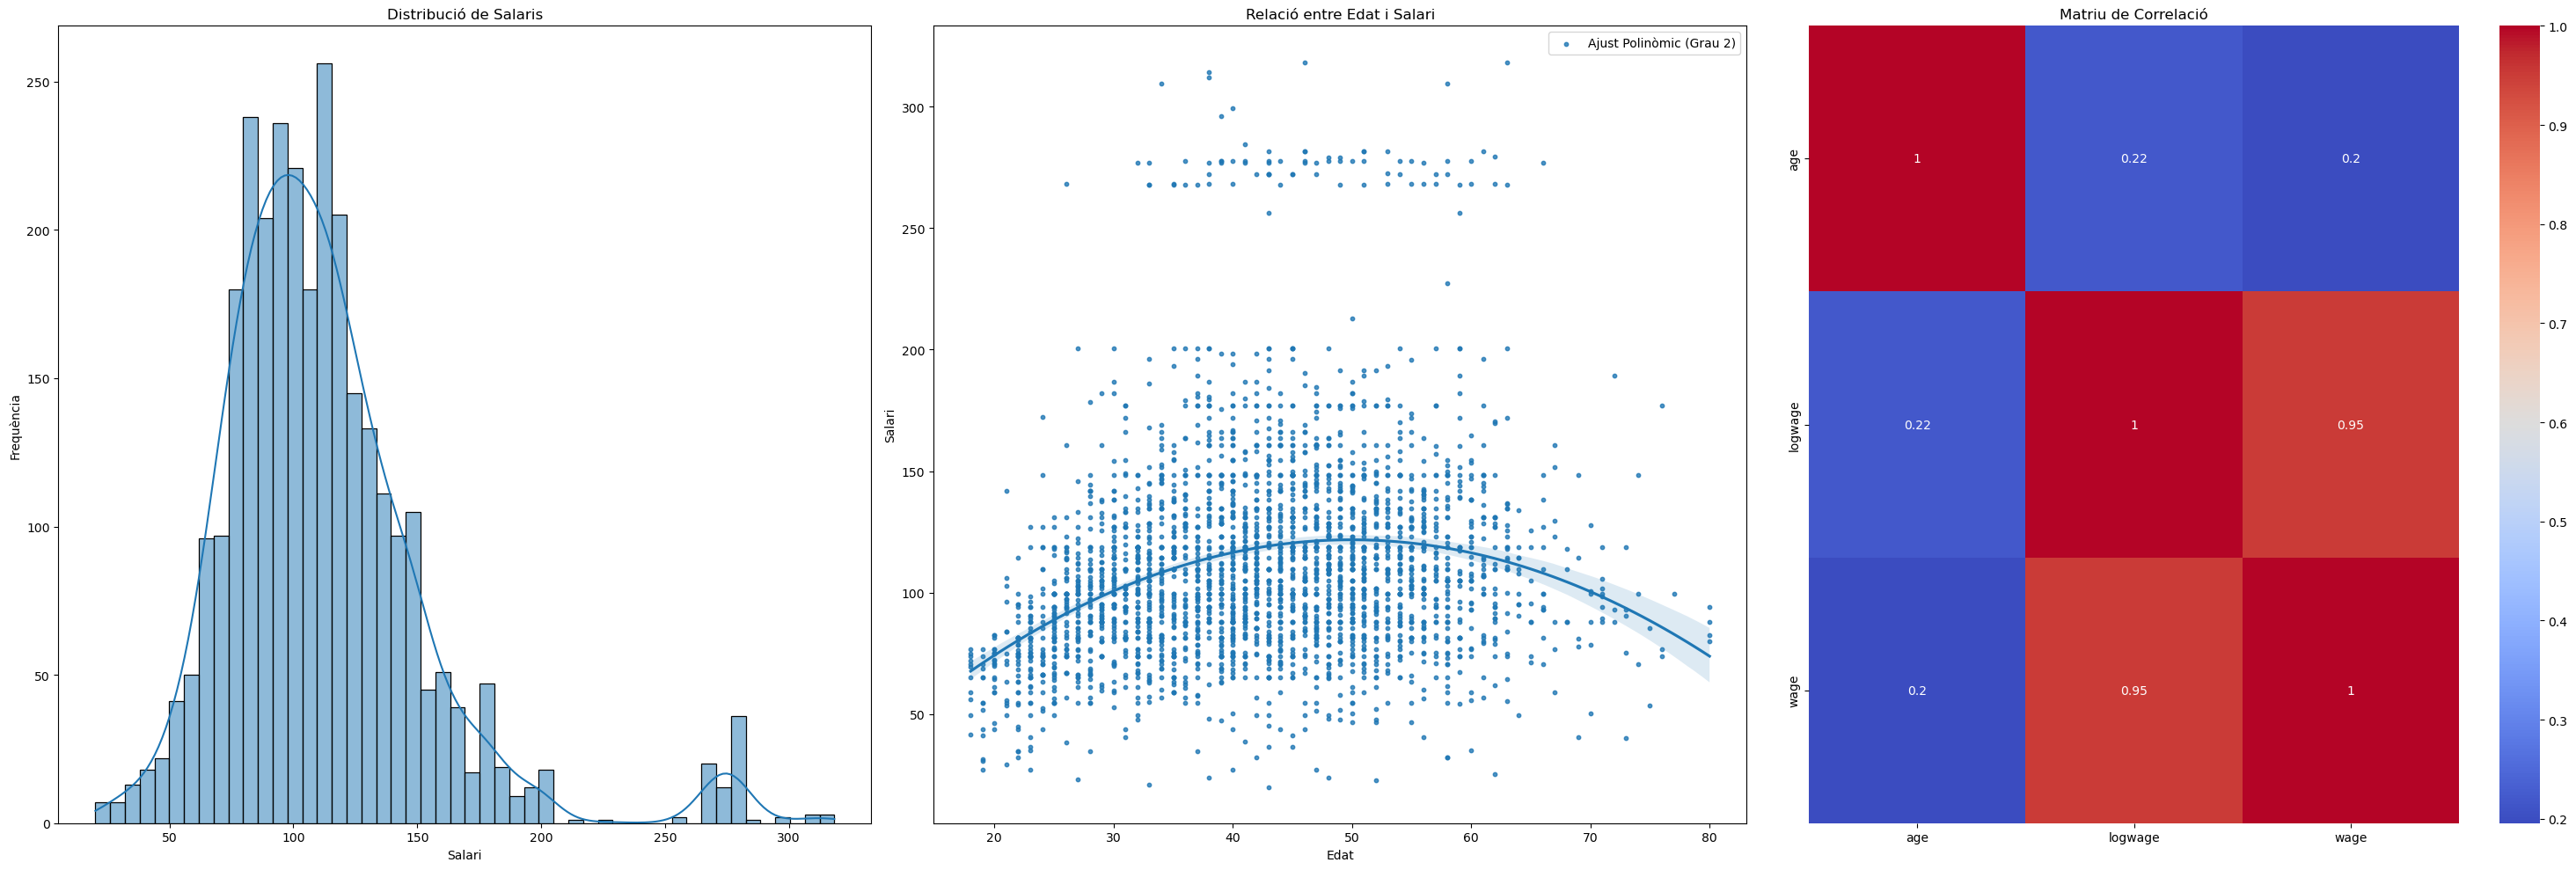

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10)) # 1 fila, 3 columnas

# Visualització de la distribució dels salaris
sns.histplot(df['wage'], kde=True, ax=axes[0])
axes[0].set_title('Distribució de Salaris')
axes[0].set_xlabel('Salari')
axes[0].set_ylabel('Frequència')

# Relació entre edat i salari
sns.regplot(x='age', y='wage', data=df, order=2, ax=axes[1], label="Ajust Polinòmic (Grau 2)", scatter_kws={"s": 10})
axes[1].set_title('Relació entre Edat i Salari')
axes[1].set_xlabel('Edat')
axes[1].set_ylabel('Salari')
axes[1].legend()


# Correlació entre variables numèriques
correlation_matrix = df[['age', 'logwage', 'wage']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Matriu de Correlació')

plt.tight_layout() # Ajusta l' espaiat 
plt.show()

## <font color="red"><b>Exercici 6</b></font>
Explicació en un paràgraf per cada punt:

1. **Què es pot dir de l'histograma del salari?**  
   És gaussià?, amb un pic clar i desviació simètrica? Què pot significar que hi hagi dos pics?

Podriem assimilar l'histograma com una Gaussiana, ja que en el seu lóbul principal compleix tots els requisits esmentats. Encara que podem notar que tenim un segon lóbul que representa un salaris molt més alts. Això és degut a un nivell de salir molt més elevats però menys freqüents. Ho podem assimilar al exemple del polític espanyol que va possar el professor Enric Monte a classe.

3. **Des del punt de vista sociològic, es pot explicar que la dependència del salari amb l'edat sigui quadràtica?**  
   Es pot observar que hi ha dues poblacions?

Podem veure que la forma representa que en perfil més joves el salari es menor, va creixent fins a un punt de inflexió aproximadament sobre els 50 anys quan comença a decreixer. Això potser degut per diversos factor, les persones quan arriben a la tercera edates jubilen, no solen treballar, per això a lo millor començen a tenir menys fons d'ingressos, coses per aquest estil.

5. **En el diagrama de correlació, es pot explicar per què un dels dos (salari o logSalari) té una dependència més gran amb l'edat?**  
   Quina utilitat pot tenir saber-ho?

Com hem vist abans, un és una transformació de l'altre. Aquesta transformació té més similituts amb la variable de l'edat, per qual cosa aquesta diferéncia. És útil saber això, ja que potser ens és millor objectiu predir el logwage que no el wage directament.



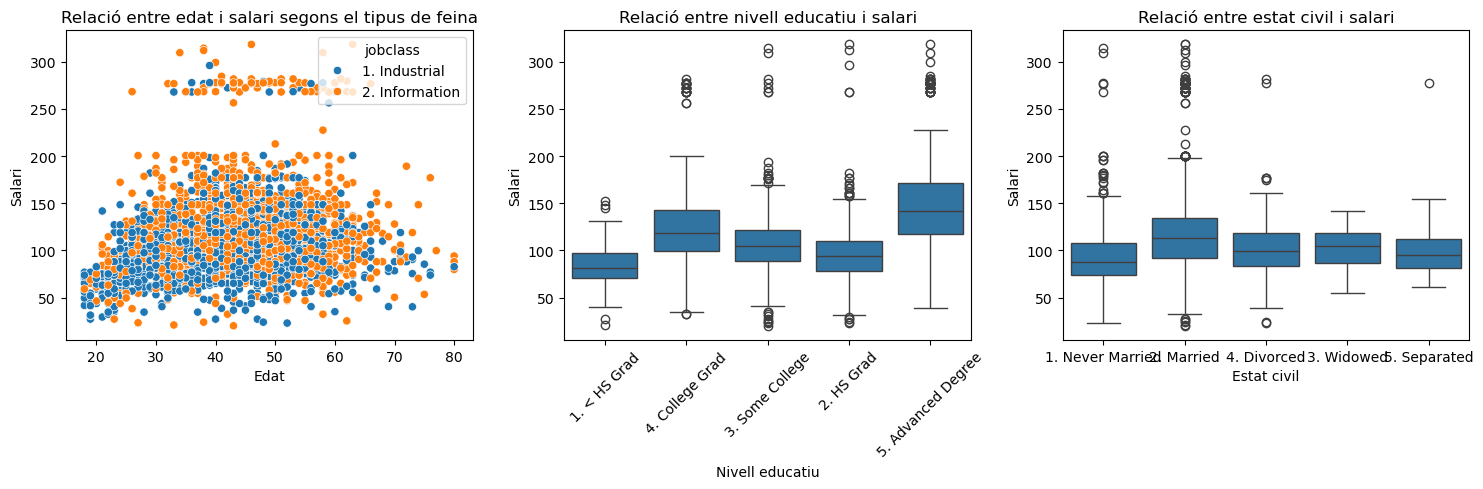

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gràfic 1: Dispersió entre edat i salari segons el tipus de feina
sns.scatterplot(x='age', y='wage', hue='jobclass', data=df, ax=axes[0])
axes[0].set_title('Relació entre edat i salari segons el tipus de feina')
axes[0].set_xlabel('Edat')
axes[0].set_ylabel('Salari')

# Gràfic 2: Boxplot entre nivell educatiu i salari
sns.boxplot(x='education', y='wage', data=df, ax=axes[1])
axes[1].set_title('Relació entre nivell educatiu i salari')
axes[1].set_xlabel('Nivell educatiu')
axes[1].set_ylabel('Salari')
axes[1].tick_params(axis='x', rotation=45) # Rotació de les etiquetes de l'eix x

# Gràfic 3: Boxplot entre estat civil i salari
sns.boxplot(x='maritl', y='wage', data=df, ax=axes[2])
axes[2].set_title('Relació entre estat civil i salari') # Títol corregit
axes[2].set_xlabel('Estat civil') # Etiqueta eix x corregida
axes[2].set_ylabel('Salari')
axes[2].tick_params(axis='x', rotation=0) # Rotació de les etiquetes de l'eix x (0 per evitar rotació)

plt.tight_layout() # Ajusta el disseny per evitar solapaments
plt.show()

## <font color="red"><b>Exercici 7</b></font>

Respondre en un paràgraf per cada punt.

1. **Diagrama de dispersió:**
    Existeix tendència entre edat i salari? Hi ha (en promig) alguna diferència entre tenir feines industrial i en informació?

Sembla haver-hi certa tendència, pero sobretot és veu tendència entre el tipus de treball. Observem que en general el sector de 
"Information" tenen millor salari, en totes les edats.
   

3. **Educació vs. Salari:**
    Hi ha alguna tendència en la mediana (percentil 50%)? Té sentit que hi hagin outliers (valors atípics) altament improbables?

Els percentils 50% sembla comportar-se de forma bastant similar, encara que "Advanced Degree" i "College Grad" son una mica més amplis, pero si que és veritat que hi han moltissim outliers. Té sentit que hi hagin outliers, perquè els salaris normalment son molt diversos tant para dalt com para abaix. 

5. **Estat civil vs. Salari:**
    Hi ha alguna tendència en la mediana (percentil 50%)? Té sentit que hi hagin outliers (valors atípics) altament improbables?

Els percentils 50% aquí si que són pràcticament identics, tornem a veure tema de outliers, que la resposta potser paral·lela amb l'anterior, tenen sentit i son els esperables.


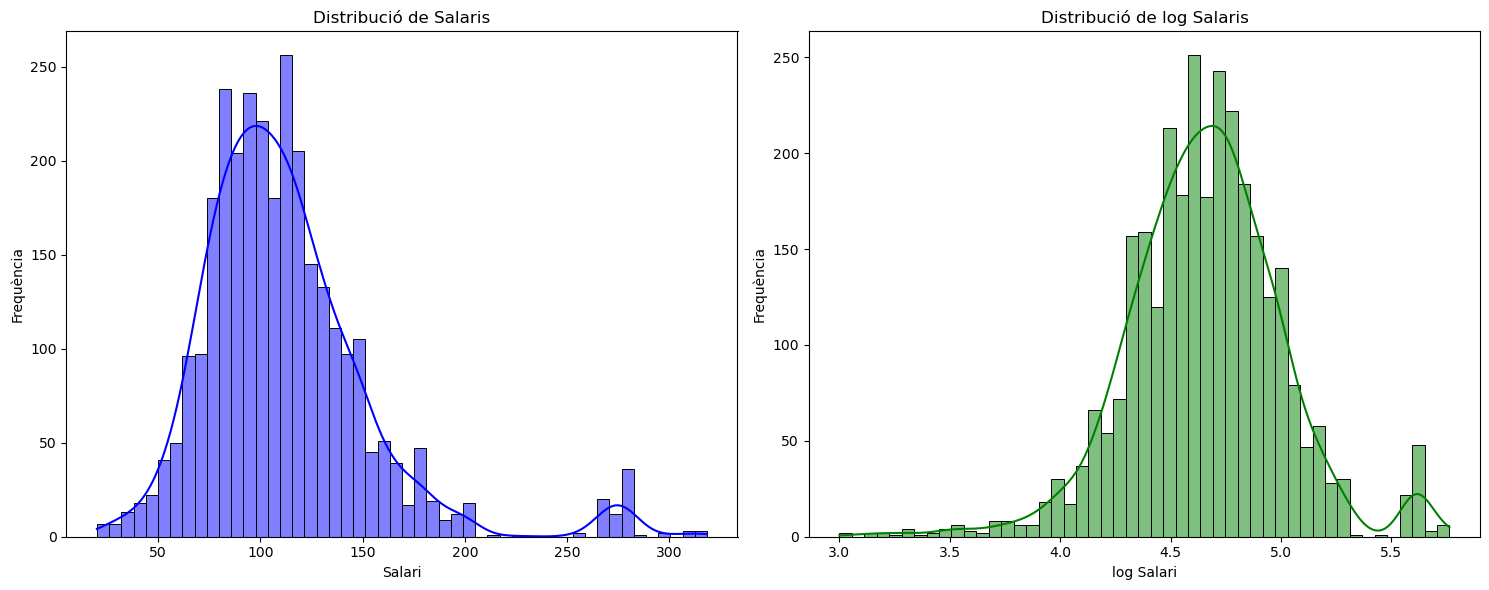

,mean,std,min,25%,50%,75%,max
wage,111.704,41.729,20.086,85.384,104.922,128.680,318.342
logwage,4.654,0.352,3.000,4.447,4.653,4.857,5.763


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) #

# Visualització de la distribució dels salaris
sns.histplot(df['wage'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribució de Salaris')
axes[0].set_xlabel('Salari')
axes[0].set_ylabel('Frequència')

# Visualització de la distribució del log salaris
sns.histplot(df['logwage'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribució de log Salaris')
axes[1].set_xlabel('log Salari')
axes[1].set_ylabel('Frequència')

plt.tight_layout() # Ajusta l' espaiat 
plt.show()
df[[ 'wage', 'logwage']].describe().round(3).T.iloc[:,1:]

## <font color="red"><b>Exercici 8</b></font>
Respon en un paràgraf.

1. Justifica per què la transformació logarítmica crea una distribució **més gaussiana**.
* **Nota**: El mètode de regressió lineal assumeix que les variables tenen una distribució gaussiana, amb simetria al voltant del valor mitjà.

Aquesta crea una distribució més Gaussiana degut a que baixa de gran forma la variació estandard i manté una major simetria a ambos costats del percentil 50%.

## 3.1.3. Codificació de variables categòriques per a la regressió
- **LabelEncoder** transforma variables categoriques en etiquetes numériques.
- **Nota**: alternativa a la funció <u> **.map()** </u>, d'altes pràctiques

In [12]:

le = LabelEncoder()
df['maritl_encoded'] = le.fit_transform(df['maritl'])
df['race_encoded'] = le.fit_transform(df['race'])
df['education_encoded'] = le.fit_transform(df['education'])
df['jobclass_encoded'] = le.fit_transform(df['jobclass'])
df['health_encoded'] = le.fit_transform(df['health'])
df['health_ins_encoded'] = le.fit_transform(df['health_ins'])
encoded_variables = ['maritl_encoded', 'race_encoded', 'education_encoded', 'jobclass_encoded', 'health_encoded', 'health_ins_encoded']
df[encoded_variables].head(10).T

,0,1,2,3,4,5,6,7,8,9
maritl_encoded,0,0,1,1,3,1,1,0,0,1
race_encoded,0,0,0,2,0,0,3,2,1,0
education_encoded,0,3,2,3,1,3,2,2,2,1
jobclass_encoded,0,1,0,1,1,1,0,1,1,1
health_encoded,0,1,0,1,0,1,1,0,1,1
health_ins_encoded,1,1,0,0,0,0,0,0,0,0


## <font color="red"><b>Exercici 9</b></font>
Respon en un paràgraf.
1. Justificar en una línea la ncesitat de passar de variable categòrica a numèrica.
*    **Pista**: Pensar en termes de $y = \sum_{j=1}^{p} \beta_j x_{ij}$

Si no passem de variables categòriques a numèriques no podem fer calculs. Necessitem que totes les variables siguin numeriqués, no podem calcular la mitjà d'un conjunt de Strings, no té cap sentit.

## 3.1.4. Matriu de correlació per variables numèriques

####  **Recordatori** de la definició formal de la Funció de Correlació

El coeficient de correlació entre dues variables $ X $ i $ Y $ és el coeficient de correlació de Pearson $ r $, que es calcula com:

$r_{X,Y} = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$

On:
- $ n $ és el nombre de parells de puntuacions.
- $ X_i $ i $ Y_i $ són els punts de mostra individuals indexats amb $ i $.
- $ \bar{X} $ i $ \bar{Y} $ són les mitjanes de $ X $ i $ Y $, respectivament.

Recordatori dels valors de cada variable  categorica:

| Variable      | Codi Numèric | Descripció                                  |
|---------------|--------------|----------------------------------------------|
| `maritl`      | 1            | Never Married (Mai Casat)                       |
|               | 2            | Married (Casat/Casada)                        |
|               | 3            | Widowed (Vidu/Vídua)                           |
|               | 4            | Divorced (Divorciat/Divorciada)                 |
|               | 5            | Separated (Separat/Separada)                   |
| `race`        | 1            | White (Blanc/Blanca)                           |
|               | 2            | Black (Negre/Negra)                            |
|               | 3            | Asian (Asiàtic/Asiàtica)                        |
|               | 4            | Other (Altres)                                |
| `education`   | 1            | < HS Grad (Sense graduat d'ESO/Batxillerat)    |
|               | 2            | HS Grad (Graduat d'ESO/Batxillerat)            |
|               | 3            | Some College (Alguns estudis universitaris) |
|               | 4            | College Grad (Graduat universitari)             |
|               | 5            | Advanced Degree (Postgrau/Màster/Doctorat)     |
| `health`      | 1            | <=Good (<=Bo/Bona)                             |
|               | 2            | >=Very Good (>=Molt Bo/Molt Bona)                |
| `health_ins`  | 1            | Yes (Sí)                                      |
|               | 2            | No (No)                                       |

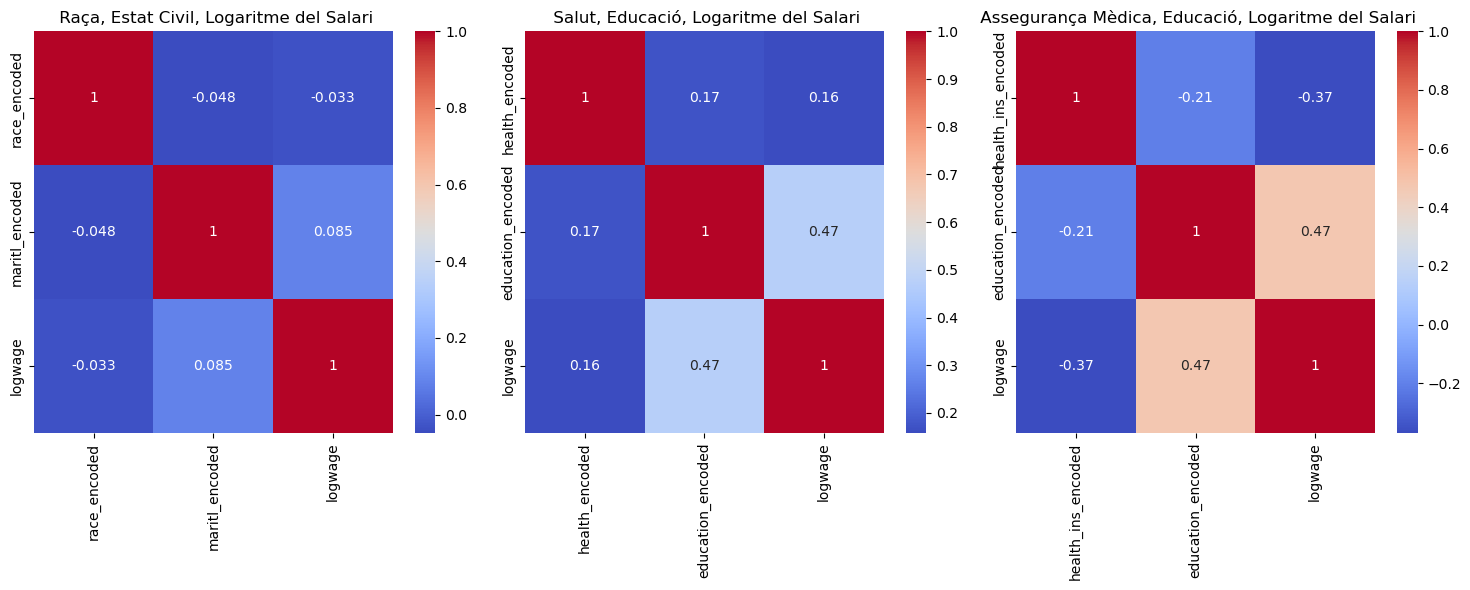

In [13]:
# Creem la figura amb 1 fila i 3 columnes
fig, axes = plt.subplots(1, 3, figsize=(15, 6))  # Ajustem figsize segons sigui necessari

# Calculem les matrius de correlació per a cada conjunt de variables
matriu_corr1 = df[['race_encoded', 'maritl_encoded', 'logwage']].corr()
matriu_corr2 = df[['health_encoded', 'education_encoded', 'logwage']].corr()
matriu_corr3 = df[['health_ins_encoded', 'education_encoded', 'logwage']].corr()

# Dibuixem els mapes de calor a cada subplot amb anotacions i mapa de colors
sns.heatmap(matriu_corr1, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title(' Raça, Estat Civil, Logaritme del Salari')
axes[0].set_xlabel('')  # Eliminem l'etiqueta predeterminada de l'eix x
axes[0].set_ylabel('')  # Eliminem l'etiqueta predeterminada de l'eix y

sns.heatmap(matriu_corr2, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title(' Salut, Educació, Logaritme del Salari')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

sns.heatmap(matriu_corr3, annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title(' Assegurança Mèdica, Educació, Logaritme del Salari')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

# Ajustem el disseny per evitar que els elements se superposin
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 10</b></font>
Respon en un paràgraf.

1. Figura 1: Raça, Estat Civil, Logaritme del Salari
- **Quina és la correlació més alta entre aquestes variables?**
La correlació més alta de la figura és la de "logwage" amb "maritl_encoded".

- **Hi ha alguna correlació negativa destacable?**
Hi han dos correlacions negatives destacables: race_encoded-maritl_encoded i race_encoded i logwage.


- **Com interpreteu el signe de la correlació entre "Raça" i "Logaritme del Salari"? (veure codificació)**
Tenim una correlació negativa, el que vol dir que quan una variable augmenta l'altre disminueix, i a la inversa.

2. Figura 2: Salut, Educació, Logaritme del Salari
- **Quina variable té la correlació més forta amb el "Logaritme del Salari"?**
Logwage-education_encoded.

- **Hi ha alguna correlació feble o propera a zero?**
La correlació més propera a zero és la de logwage-health_encoded = 0.16.

- **Com interpreteu el signe de la correlació entre "Salut" i "Educació"?**
És una correlació positiva, si una augmenta l'altre yambé i viceversa.



3. Figura 3: Assegurança Mèdica, Educació, Logaritme del Salari
- **Com afecta l'"Assegurança Mèdica" el "Logaritme del Salari"?**
Tenim una correlació negativa, si una augmenta l'altra disminueix i al inreves.

- **La correlació entre "Educació" i "Logaritme del Salari" és positiva o negativa?**
És positiva.

- **Hi ha algun patró evident en la correlació entre "Assegurança Mèdica" i "Educació"?**
No entenc exactament amb que ens referim amb "patró" tenim una correlació entre elles de -0.21. La correlació de ambues amb logwage és igual si la canviem de signe i le sumem o restem 0.1.


## 3.2. Predicció amb les técniques: Regressio i lasso.

Variables: Predicció de Salaris i Tipus de Treball:

## 3.2.1. Repartim les dades en bases d'entrenament i test i  Estandarització de les dades.

* Justificació de repartir les dades en bases d'entrenament i test: Dividim el conjunt de dades en un conjunt d'entrenament (80% de les dades) i un conjunt de prova (20% de les dades) utilitzant train_test_split. Això ens permet entrenar el model amb una part de les dades i provar-ne el rendiment amb una altra part que no ha estat utilitzada per a l'entrenament.
* Justificació de l'estandarització de les dades: Vegeu l'explicació més avall.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Carreguem el DataFrame 
file_path = 'Wage.csv'  
df = pd.read_csv(file_path)
# Codifiquem les variables categòriques
le = LabelEncoder()
categorical_columns = ['maritl', 'race', 'education', 'jobclass', 'health', 'health_ins','region']
for col in categorical_columns:
    df[col + '_encoded'] = le.fit_transform(df[col])

# Seleccionem les característiques i la variable objectiu
features = ['age', 'year'] + [col + '_encoded' for col in categorical_columns]
X = df[features]
y = df['logwage']  # Utilitzem 'logwage' per evitar problemes amb la regressió lineal

# Dividim les dades en conjunt de entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalitzem les dades
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print('**Nota**: Existeixen altres maneres de codificar que en alguns casos funcionen millor. \n \n')
X.head()

**Nota**: Existeixen altres maneres de codificar que en alguns casos funcionen millor. 
 



,age,year,maritl_encoded,race_encoded,education_encoded,jobclass_encoded,health_encoded,health_ins_encoded,region_encoded
0,18,2006,0,0,0,0,0,1,0
1,24,2004,0,0,3,1,1,1,0
2,45,2003,1,0,2,0,0,0,0
3,43,2003,1,2,3,1,1,0,0
4,50,2005,3,0,1,1,0,0,0


## 3.2.2. Necesitat d'estandaritzar  les variables
**Explicació:**

La normalització de dades és una tècnica que ajusta les característiques (features) d'un conjunt de dades de manera que tinguin la mateixa escala. Això és especialment útil en models d'aprenentatge automàtic on les característiques tenen diferents rangs o unitats de mesura. 

**StandardScaler** realitza una estandardització, que transforma les dades de manera que tinguin una mitjana de zero i una desviació estàndard de 1. La fórmula per estandarditzar una característica $x_i$ és:

$ z_i = \frac{x_i - \mu}{\sigma} $

On:
- $z_i$ és la característica estandarditzada.
- $x_i$ és la característica original.
- $\mu$ és la mitjana de la característica sobre el conjunt de dades d'entrenament.
- $\sigma$ és la desviació estàndard de la característica sobre el conjunt de dades d'entrenament.

**Detalls de les Comandes:**

- `scaler = StandardScaler()`: Crea una instància de `StandardScaler`, que és la classe de scikit-learn que realitza aquesta transformació. Aquesta instància encara no ha estat ajustada als nostres dades.
- `X_train_scaled = scaler.fit_transform(X_train)`:
  - **`.fit_transform(X_train)`**: 
    - **Fit**: Calcula la mitjana ($\mu$) i la desviació estàndard ($\sigma$) per cada característica en `X_train`. 
    - **Transform**: Utilitza aquests paràmetres per transformar les dades d'entrenament (`X_train`) en les noves característiques estandarditzades (`X_train_scaled`). Cada valor $x_i$ de `X_train` es converteix en $z_i$ segons la fórmula anterior.

**Per què ho fem:**

- **Evitar Bias**: Característiques amb rangs més amples poden tenir un pes més gran en models com la regressió, si no s'estandarditzen.
- **Millorar el Rendiment**: Alguns algorismes d'aprenentatge, especialment els basats en gradients com les xarxes neuronals, funcionen millor o convergeixen més ràpid quan les dades estan normalitzades.
- **Facilitar la Interpretació**: Amb dades estandarditzades, els coeficients dels models són més comparables entre si.

Aquesta normalització es faria per separat per al conjunt de prova amb `scaler.transform(X_test)` per assegurar-se que utilitzem els mateixos paràmetres d'escala (mitjana i desviació estàndard) calculats amb el conjunt d'entrenament.

In [18]:
pd.DataFrame(X_train,columns = X.columns).describe().iloc[1:3].round(2)

,age,year,maritl_encoded,race_encoded,education_encoded,jobclass_encoded,health_encoded,health_ins_encoded,region_encoded
mean,42.30,2005.77,0.98,0.27,2.03,0.49,0.71,0.30,0.0
std,11.53,2.02,0.81,0.64,1.21,0.50,0.45,0.46,0.0


In [19]:
pd.DataFrame(X_train_scaled,columns = X.columns).describe().iloc[1:3].round(2)


,age,year,maritl_encoded,race_encoded,education_encoded,jobclass_encoded,health_encoded,health_ins_encoded,region_encoded
mean,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


## <font color="red"><b>Exercici 11</b></font>
Per aclarir idees, explicar en paràgraf per què és necesari fer un procés d'estandarització de les dades $ z_i = \frac{x_i - \mu}{\sigma} $.
Fer servir en l'explicació les diferències X_train i X_train_scaled que es presenten més amunt

Hem d'estadaritzar les dades para que totes presentin magnituds del mateix ordre i mantinguin una importància igual per al model. Si entrenem el model amb X_train tenim dades de valors molt dispersos, per exemple year en pot solapar el valor de la variable maritl_encoded, ja que la primera té de mitjana aritmética (mean) 2005.77 i la segona 0.98. En canvi, si ho fem amb X_train_scaled això no passa més, tenen el mateix ordre de magnitud. La primera tenint una mitjana aritmética de -0.0 i la segona de 0.0. És important recalcar que les desviacions estardard també eran molt diferents sense estandaritar (1ª/ 2.02 2ª/ 0.81) i en canvi estandaritzant ambdues són de 1.

## 3.2.3. *Predicció Lineal* del logaritme del salari amb  Regressió Lineal

Aquí utilitzem una regressió lineal bàsica per predir el logaritme del salari. La normalització és important per mantenir les escales de les característiques uniformes.

In [20]:
# Regressió Lineal
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediccions
y_pred = model.predict(X_test_scaled)

# Avaluem el model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Error Mitjà Quadrat (MSE): {mse}')
print(f'Coeficient de Determinació (R²): {r2}')

Error Mitjà Quadrat (MSE): 0.06862381162874999
Coeficient de Determinació (R²): 0.37582487645097684


## 3.2.3. Explicació dels criteris de qualitat: Error Mitjà Quadrat (MSE)

L'**Error Mitjà Quadrat (MSE)** és una mesura de l'error d'un model que ens informa sobre la qualitat de les prediccions en termes de desviació quadrada mitjana entre les prediccions i els valors reals. La fórmula per calcular el MSE és:

$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $

On:
- $n$ és el nombre de mostres.
- $y_i$ és el valor real o observat per a l'element $i$.
- $\hat{y}_i$ és la predicció del model per a l'element $i$.

**Interpretació:**
- **Més baix és millor**: Un MSE baix significa que les prediccions del model estan molt properes als valors reals, indicant un bon ajust del model.
- **Indica precisió**: Utilitzem MSE per comparar models, ja que un valor més baix suggereix un millor ajustament al conjunt de dades.

## 3.2.4. Descripció gràfica del significat del MSE.

![Explicacio MSE 1.png](ExplicacioMSE_1.png)

## <font color="red"><b>Exercici 12</b></font>
1. Interpreta el significat de cada terme de l'equació de l'Error Quadrat Mitjà (MSE) i explica com es relaciona amb la informació visualitzada a la figura.
 
L'equació representada a la figura és: $ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $

**Pistes:**

*   Pensa en el terme $(y_i - \hat{y}_i)$ i la seva relació amb els punts marcats a la figura.
*   Què representa la suma $\sum_{i=1}^{n}$ ?
*   Com influeix el terme $\frac{1}{n}$ en el valor final del MSE?
*   Com es relaciona el valor del MSE amb la dispersió dels punts al voltant de la línia perfecta?

la restra representa la diferencia entre valor real i valor predit. Amb el MSE calculem totes les distancies al quadrat de les nostres variables, sumades i normalitzades. Ens fixem que si MSE fos sempre 0, en comptes dels punts dispersos tindriem aquesta recta puntejada feta de punts, aquesta recta  ens relaciona el Valor REAL amb el Valor PREDIT que en aquest cas seria una relació un a un. 


## 3.2.5.  Coeficient de Determinació (R²)

El **Coeficient de Determinació (R²)**, també conegut com a R quadrat, mesura la proporció de la variància de la variable dependent que és explicada per les variables independents en el model. La fórmula per calcular $R^2$ és:

$ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $

On:
- $y_i$ és el valor real o observat per a l'element $i$.
- $\hat{y}_i$ és la predicció del model per a l'element $i$.
- $\bar{y}$ és la mitjana dels valors reals de $y$.

**Utilitat:**
- **Valor entre 0 i 1**: $R^2$ pot ser des de 0 fins a 1. Un valor de 1 indica que el model explica tota la variabilitat de les dades dependents, mentre que un valor de 0 indica que el model no explica cap variabilitat més enllà de la que faria una mitjana simple.
- **Interpretació**: Un $R^2$ alt suggereix que el model té una bona capacitat de predicció, ja que explica una gran part de la variància observada. No obstant això, cal tenir en compte que un alt $R^2$ no sempre significa un model bo, especialment en presència d'overfitting o amb moltes variables.

## 3.2.6. Descripció gràfica del significat del Coeficient de Determinació (R²).

![Explicacio_R2_1.png.png](Explicacio_R2_1.png)

## <font color="red"><b>Exercici 13</b></font>
1. Interpreta el significat de cada terme de l'equació del Coeficient de Determinació (R²) i explica com es relaciona amb la informació visualitzada a la figura.

L'equació representada a la figura és: $ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $

**Pistes:**

*   Recorda el significat del terme $(y_i - \hat{y}_i)$ del MSE. Com es representa a la figura?
*   Què representa el terme $(y_i - \bar{y})$? Com es visualitza a la figura?
*   Com influeix la relació entre les dues sumes en el valor final del R²?
*   Com es relaciona el valor de R² amb la qualitat de l'ajust del model?

El primer terme són els punts, que es la diferencia entre valor real i predit.
El segon terme es la diferencia entre el valor real i la mitja de valors reals de y.
El valor de la divisió de ambdues restes se li resta a 1.
Volem un valor de 1, o un valor gran que no representi que el nostre model funciona incorrectament.


## 3.2.7.  Interpretació dels coeficients de la regressió lineal.
### * **Important**

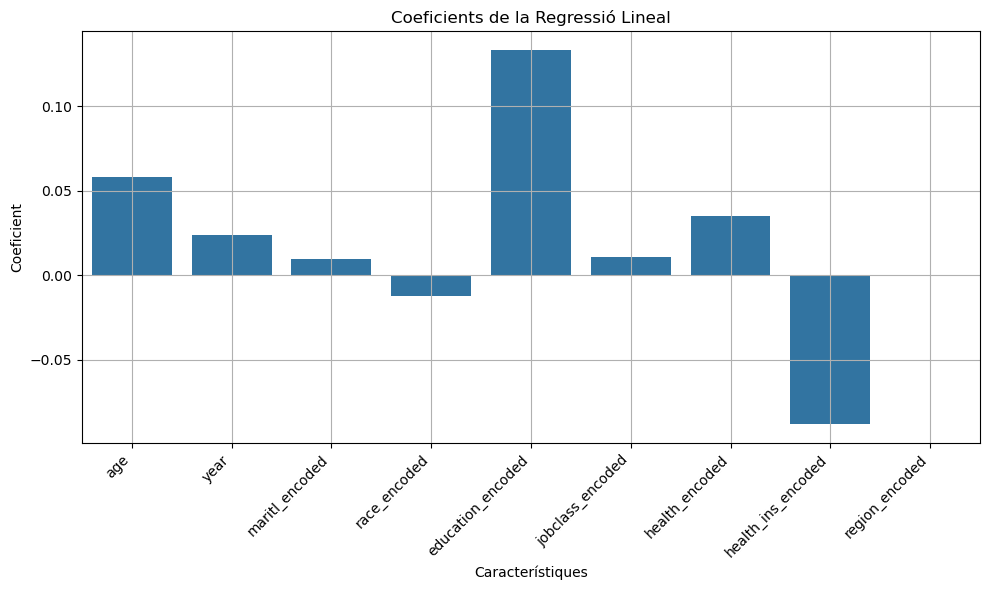

In [21]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Ordenar els coeficients per magnitud per fer el gràfic més llegible
#coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

# Crear el gràfic de barres
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coef_df)

# Ajustar les etiquetes i títol
plt.title('Coeficients de la Regressió Lineal')
plt.xlabel('Característiques')
plt.ylabel('Coeficient')
plt.xticks(rotation=45, ha='right')  # Rotar les etiquetes per visibilitat
plt.grid()
# Mostrar el gràfic
plt.tight_layout()
plt.show()

In [22]:
coef_df.round(2).T

,0,1,2,3,4,5,6,7,8
Feature,age,year,maritl_encoded,race_encoded,education_encoded,jobclass_encoded,health_encoded,health_ins_encoded,region_encoded
Coefficient,0.06,0.02,0.01,-0.01,0.13,0.01,0.04,-0.09,0.0


## <font color="red"><b>Exercici 14</b></font>
Exercici important:
$logwage = 0.06 \cdot \text{age} + 0.02 \cdot \text{year} + 0.01 \cdot \text{maritl} - 0.01 \cdot \text{race} + 0.13 \cdot \text{education} + 0.01 \cdot \text{jobclass} + 0.04 \cdot \text{health} - 0.09 \cdot \text{health\_ins} + 0.0 \cdot \text{region}$
1. Redactar en un paràgraf la interpretació de la ponderació que es fa per a cada variable (estandaritzada) per tal de calcular el **logwage**.

* Què vol dir el signe de cada coeficient?
El signe de cada coeficient representa l'aportació que fa cada variable a la nostra predicció.

* El fet d'estandaritzar, què implica de cara a interpretar els coeficients?
El fet d'estandaritzar fa que tots els coeficients siguin de la mateixa magnitud.

* Hi ha coeficients redundants o que tenen poca capacitat predictiva?
Si, si veiem region_encoded és igual a zero, el que vol dir que no ens donà cap informació de cara a nostra predicció.
  
* Si hagués de fer una recomanació a algú que volgués entendre la dependència entre el salari i les variables, què li podria dir?
Li diria que cada variable ens aporta una quantitat numérica a la nostra predicció, pero no totes les variables són exactament igualment de importants. Aquesta importància de cada variable la marquen els coeficients de la Regressió Lineal.

## 3.2.8.  Regressió Regularitzada: Lasso

La regressió Lasso (Least Absolute Shrinkage and Selection Operator) afegirà un terme de penalització que pot reduir alguns coeficients a zero, realitzant així una **selecció de característiques** implícita.
Elimina:
1. Coeficients que són redundants.
2. Combinacions lineals que poden explicar altres variables. (identificar una combinació lineal exacta que expliqui completament una altra variable i després eliminar-la.)

In [23]:
# Regressió Lasso
alpha_lasso = 0.05
lasso = Lasso(alpha=alpha_lasso)  # 'alpha' és el paràmetre de regularització
lasso.fit(X_train_scaled, y_train)

# Prediccions
y_pred_lasso = lasso.predict(X_test_scaled)

# Avaluem el model Lasso
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f'Error Mitjà Quadrat (Lasso): {mse_lasso}')
print(f'Coeficient de Determinació (Lasso): {r2_lasso}')

Error Mitjà Quadrat (Lasso): 0.07492296071802665
Coeficient de Determinació (Lasso): 0.3185303008840644


![MSER2Lasso](MSE_R2_Lasso.png)

## <font color="red"><b>Exercici 15</b></font>
1. Comparar els diagrames de dispersió i els valors de MSE i $R^2$ respecte a la regressió lineal clàssica.

* És millor o pitjor, quant a valors numèrics i diferències quant a dispersió?
* Nota: en el cas ideal, el diagrama de dispersió hauria de ser una recta, sense valors laterals.

Sembla ser que la Regressió Lasso és una mica pitjor que la regressió lineal classica. La Lasso té un MSE més gran y un R^2 més baix. També sembla que els punts estiguin una mica més disperssos que en al Regressió classica. 

Això és normal perquè el metode Lasso simplifica el model eliminant variables que considera menys importants (les elimina amb la penalització). En tenir "menys informació", s'ajusta una mica pitjor a les dades concretes, pero a canvi tenim un model més simple i que no es fixa tant en el soroll de les dades.




## 3.2.9.  Interpretació dels coeficients de la regressió LASSO.
### * **Important**

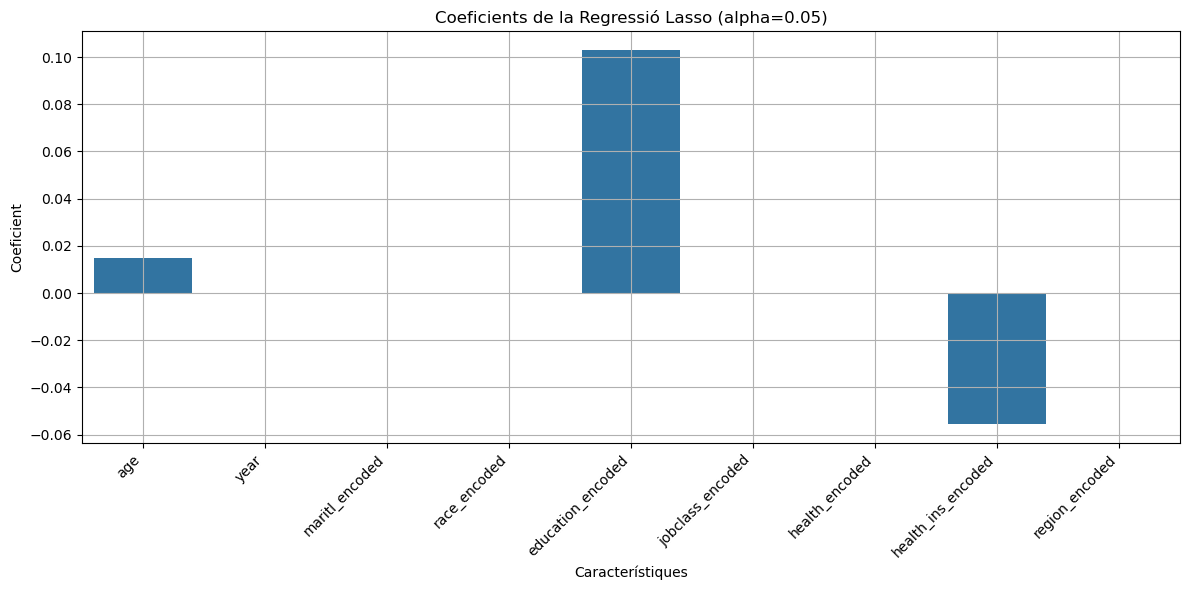

In [24]:
# Crear un DataFrame amb els coeficients del model Lasso
coef_df_lasso = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

# Ordenar els coeficients per magnitud per fer el gràfic més llegible
#coef_df_lasso = coef_df_lasso.sort_values(by='Coefficient', key=abs, ascending=False)

# Crear el gràfic de barres per als coeficients de Lasso
plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Coefficient', data=coef_df_lasso)

# Ajustar les etiquetes i títol
plt.title(f'Coeficients de la Regressió Lasso (alpha={alpha_lasso})')
plt.xlabel('Característiques')
plt.ylabel('Coeficient')
plt.xticks(rotation=45, ha='right')  # Rotar les etiquetes per visibilitat
plt.grid()
# Mostrar el gràfic
plt.tight_layout()
plt.show()

In [25]:
coef_df_lasso.round(2).T

,0,1,2,3,4,5,6,7,8
Feature,age,year,maritl_encoded,race_encoded,education_encoded,jobclass_encoded,health_encoded,health_ins_encoded,region_encoded
Coefficient,0.01,0.0,0.0,-0.0,0.1,0.0,0.0,-0.06,0.0


## <font color="red"><b>Exercici 16</b></font>
Exercici important:

$
logwage = 0.01 \cdot \text{age} + 0.1 \cdot \text{education} - 0.06 \cdot \text{health\_ins}
$
1. Comparar els coeficients de la regressió LASSO amb la regressió lineal.
   * Què vol dir que hi hagin coeficients exactament iguals a zero.
Això vol dir que aquest coeficients sobraven, per ser redundants o per ser combinacions lineals provinents de altres. S'han eliminat amb la penalització que introdueix aquesta regressió.

   * Què vol dir el signe de cada coeficient?
El tipus de aportació que fa a la predicció.
  

   * El fet d'estandaritzar, què implica de cara a interpretar els coeficients?
El fet d'estandaritzar implica que fem que tots els coeficients passen a representar la mateixa magnitud, per demostrar una "importància" correcta.
  

   * Si hagués de fer una recomanació a algú que volgués entendre la dependència entre el salari i les variables, què li podria dir?
En aquest cas podria utilizar la fórmula directament de forma simple: Tenim tres punts important (edat, educació i assegurança de salut) aquestes variables tomen els valors que tomen, per naturalesa o per haver-se mapejat, la importancià que ha de tener cada valor d'aquestes variables ve marcada per el coeficient de regressió que la multiplica.
  


## 3.2.8.   Regressió Regularitzada: Ridge

La regressió Ridge utilitza una regularització diferent, que redueix els coeficients però no els fa arribar a zero, així que tendirà a mantenir més característiques que Lasso.

In [26]:
# Regressió Ridge
alpha_ridge = 2000
ridge = Ridge(alpha=alpha_ridge)  # 'alpha' és el paràmetre de regularització
ridge.fit(X_train_scaled, y_train)

# Prediccions
y_pred_ridge = ridge.predict(X_test_scaled)

# Avaluem el model Ridge
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f'Error Mitjà Quadrat (Ridge): {mse_ridge}')
print(f'Coeficient de Determinació (Ridge): {r2_ridge}')


Error Mitjà Quadrat (Ridge): 0.07418689737085185
Coeficient de Determinació (Ridge): 0.32522524276733134


![MSE_R2_Ridge](MSE_R2_Ridge.png)

## <font color="red"><b>Exercici 17</b></font>
1. Comparar els diagrames de dispersió i els valors de MSE i $R^2$ respecte a la regressió lineal clàssica i Lasso

* És millor o pitjor, quant a valors numèrics i diferències quant a dispersió?
* Nota: en el cas ideal, el diagrama de dispersió hauria de ser una recta, sense valors laterals.

Sembla ser que la Regressió Ridge es queda en un punt intermig: és una mica millor que la Lasso, pero continua sent pitjor que la regressió lineal classica. La Ridge té un MSE de 0.07 i un R^2 de 0.33, la qual cosa supera lleugerament els valors de la Lasso (R^2 de 0.32) pero no arriba als de la Lineal (R^2 de 0.38). Visualment, els punts continuen estant força dispersos, molt semblant als altres gràfics.

Això és normal perquè el mètode Ridge també penalitza el model per evitar l'overfitting, pero a diferència del Lasso, no elimina variables (no les posa a zero), sinó que només en redueix el pes. En mantenir totes les variables però "limitades", conserva una mica més d'informació que la Lasso (per això ajusta una mica millor), però en tenir restriccions, no s'ajusta tant a les dades com la lineal clàssica.

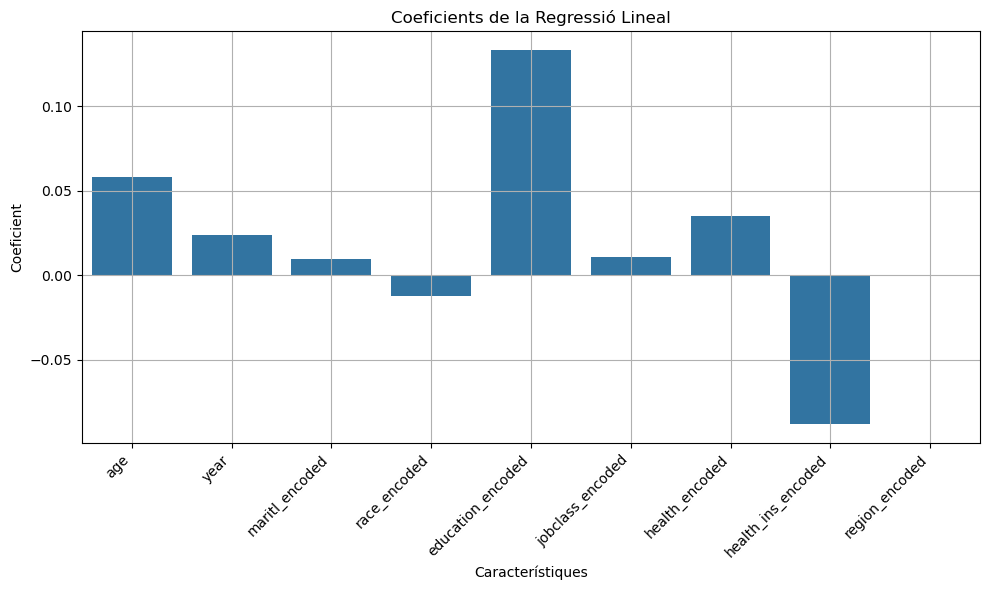

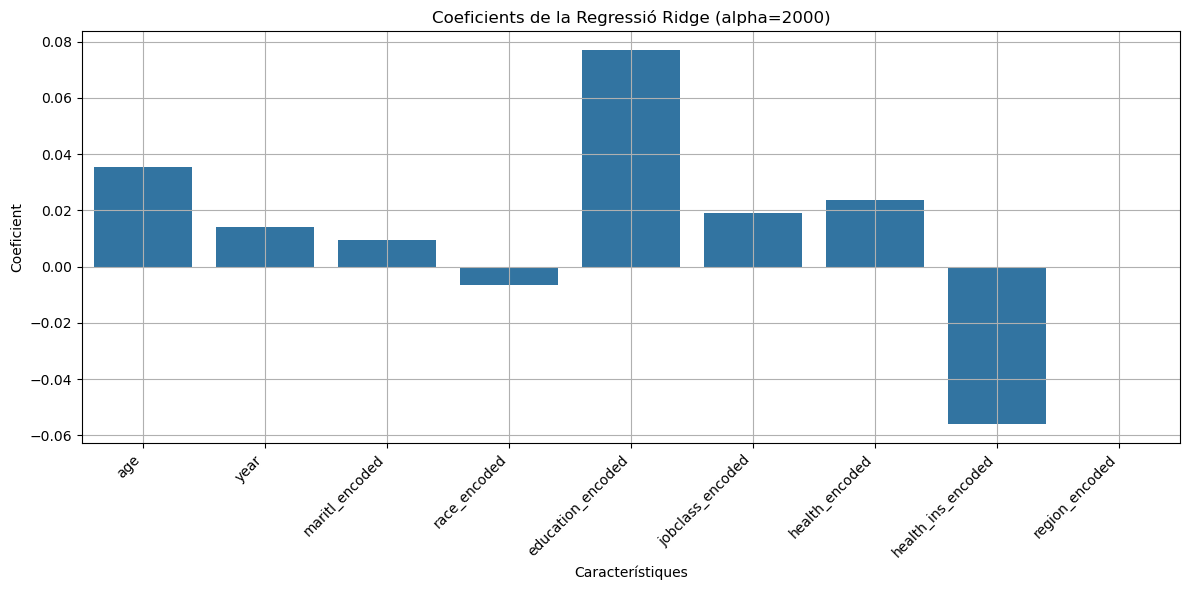

In [27]:
# Crear un DataFrame amb els coeficients del model Ridge
coef_df_ridge = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coef_df)

# Ajustar les etiquetes i títol
plt.title('Coeficients de la Regressió Lineal')
plt.xlabel('Característiques')
plt.ylabel('Coeficient')
plt.xticks(rotation=45, ha='right')  # Rotar les etiquetes per visibilitat
plt.grid()
# Mostrar el gràfic
plt.tight_layout()
plt.show()

# Ordenar els coeficients per magnitud per fer el gràfic més llegible
#coef_df_ridge = coef_df_ridge.sort_values(by='Coefficient', key=abs, ascending=False)

# Crear el gràfic de barres per als coeficients de Ridge
plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Coefficient', data=coef_df_ridge)

# Ajustar les etiquetes i títol
plt.title(f'Coeficients de la Regressió Ridge (alpha={alpha_ridge})')
plt.xlabel('Característiques')
plt.ylabel('Coeficient')
plt.xticks(rotation=45, ha='right')  # Rotar les etiquetes per visibilitat
plt.grid()
# Mostrar el gràfic
plt.tight_layout()
plt.show()

####  Comparació dels coeficients dels predictors

| Variable           |   Regressió lineal |   Regressió lineal ridge |
|:------------------|----------:|----------------:|
| age               |     0.058 |           0.036 |
| year              |     0.024 |           0.014 |
| maritl_encoded    |     0.01  |           0.009 |
| race_encoded      |    -0.012 |          -0.007 |
| education_encoded |     0.133 |           0.077 |
| jobclass_encoded  |     0.011 |           0.019 |
| health_encoded    |     0.035 |           0.024 |
| health_ins_encoded|    -0.088 |          -0.056 |
| region_encoded    |     0     |           0     |

## <font color="red"><b>Exercici 18</b></font>
Exercici important:
1. Quin és el efecte sobre els coeficients d'aplicar la regressió Ridge en aquest problema?.
La Regressió lineal Ridge ens redueix la magnitud de tots els coeficients de la Regressió lineal classica.
Per exemple:
            age/ 0.058 --> 0.036
            year/ 0.024 --> 0.014
            maritl_encoded/ 0.01 --> 0.009
   
2. Quin tipus de  un biaix introduirà en la predicció de  **logwage**?.
Podem arribar a introduir un biaix per "underfitting", ja que potser els coeficients se'ns queden curts pel nostre model, podem dir que le model és torne més rigid per representar les nostres dades d'entrenament.

3. Com és compara amb la regressió Lasso?.
La Regressió de Lasso si un coeficient es poc important l'elimina. En canvi, la Regressió de Ridge mai arriba a eliminar una variable, las pot atenuar molt, pero mai arriban a ser justament zero.SS


## 3.2.9.  Consideracions Ètiques.  <font color="red">Optatiu</font>


## <font color="red"><b>Exercici 19</b></font>
Redactar un parell de paràgraphs en relació als següents punts:
1. Com podem identificar si un model de machine learning, especialment un de predicció (com ara un de salaris), desavantatja sistemàticament certs grups demogràfics (per exemple, per raça, gènere, situació marital, edat, etc.)?
Ho podem fer separant els resultats que dona per una raça, gènere, situació marital, edat, entre altres, i comparant-los amb resultats que dona per altra grup demògrafic amb caracteristíques similars, menys justament la que se vol veure si ha discriminació.
   
2. Com podem visualitzar els biaixos presents en les prediccions d'un model?
Observant les diferencies que veiem en els resultats, per exemple les prediccions de salaris. Podem estudiar si per algun tema de racisme per exemple hi han grups etnics amb salaris molt menors, o coses per l'estil.
   
3. Quin paper juguen les dades d'entrenament en la introducció i perpetuació de biaixos en els models? Com podem analitzar les dades per detectar possibles biaixos inherents?
És important donar la maxima quantitat de dades diverses possibles per evitar que doni resultats amb biaixos per diferents grups. Encara que de vegades certes dades mostraran certs punts que poden semblar estigmes, però que potser són més presents dels que creiem.

Un exemple d'això potser el que va mencionar l'Eva Vidal en la seva xarrada pel premi de Qualitat Docent, en el que esmentava que hi existien IAs generatives que quan demanaves per exemple una imatge amb el prompt "Vull un enginyer dissenyant un avió." gairebé mai donava imatges de noies, ja que aquestes IAs generatives tenien més dades d'entrenament en les que potser li donava a entendre que ENGINYER = HOME. Cosa que per sort, no és la realitat avui en dia, on és una cosa completament diferent, ja que les dones han tomat un paper molt important en el món de l'enginyeria.

## <font color="Blue"><b>Informe Final i Recomanacions</b></font>
1. Informe on es relaciona la informació obtinguda amb l'estudi fet amb l'EDA amb els resultats obtinguts pel mètode de machine learning.
2. Recomanacions per millorar el sistema i implementar-lo.

En aquest informe volem aconseguir estudiar i estimar el salari dels treballadors (o el seu logaritme) en funció de característiques demogràfiques i laborals, utilitzant mètodes de Regressió Lineal, Lasso i Ridge. 

Primerament fem l’EDA analitzant com són les variables a tenir en compte. La variable objectiu original (wage) presenta una distribució Gaussiana amb una variació important, per la qual cosa decidim utilitzar el seu logaritme (logwage) que la disminueix de forma important, de forma que presenta una distribució molt més Gaussiana, ideal per al model lineal. Les variables predictores de les que disposem són:

year (int64)
age (int64)
maritl (object)
race (object)
education (object)
region (object)
jobclass (object)
health (object)
health_ins (object)
logwage (float64)
wage (float64)

Seguidament passem els valors no numèrics a numèrics, mapejant-los en aquest cas amb el métode labelEncoder() , per poder fer servir les fórmules de regressió. Observem que hi ha una forta correlació positiva entre el nivell educatiu i el salari, així com una relació no lineal (quadràtica) entre l'edat i el salari. Fem la separació del dataset entre train i test i, molt important, realitzem les estandaritzacions adients. Això és clau perquè totes les variables passin a tenir una importància equitativa i els coeficients siguin comparables entre ells. A continuació entrenem tres models diferents per veure quin s'ajusta millor: 

1 - Regressió Lineal Clàssica: Ens dóna el millor ajustament a les dades (R2 de 0.38 aprox), però els coeficients són més alts, cosa que podria indicar un cert overfitting al soroll de les dades. 

2 - Regressió Lasso: Introdueix una penalització que porta alguns coeficients a zero. Observem que elimina variables com region (que és irrellevant) i redueix dràsticament race o maritl, simplificant el model tot i perdre una mica de precisió (R2 de 0.32). 

3 - Regressió Ridge: Redueix la magnitud de tots els coeficients sense eliminar-los. Ens ofereix un compromís intermig entre la precisió de la lineal i l'estabilitat de la Lasso. 


Quan analitzem els coeficients obtinguts, veiem clarament quins factors influeixen més en el salari: El nivell educatiu (education) és, amb diferència, el factor més determinant per augmentar el salari (coeficient positiu més alt). L'edat (age) i tenir una bona salut (health) també tenen un impacte positiu rellevant. Per contra, no tenir assegurança mèdica (health_ins) té un coeficient negatiu destacable, indicant que penalitza el salari esperat. 

Per últim, com a milloras, destacar que la variable region té un coeficient de 0 en tots els models, indicant que no aporta cap informació per a la predicció en aquest dataset concret. Com a millora ètica, caldria vigilar si el model penalitza certs col·lectius (com per raça o gènere) analitzant els errors de predicció per grups específics.
